In [5]:
# ══════════════════════════════════════════════════════════════
# INTRODUCCIÓN A PYSPARK — Google Colab
# JOINs entre DataFrames y lectura de CSV desde URL real
# ══════════════════════════════════════════════════════════════

!pip install pyspark -q

import requests
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Arrancamos Spark
spark = SparkSession.builder \
    .appName("PySpark — JOINs y CSV") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark arrancado")
print(f"   Versión de Spark: {spark.version}")
print(f"   Núcleos disponibles: {spark.sparkContext.defaultParallelism}")


# ──────────────────────────────────────────────
# 1. LEER UN CSV DESDE UNA URL
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("1. LECTURA DE CSV DESDE URL")
print("="*55)

# Spark no puede leer directamente desde HTTP
# Lo descargamos primero con requests y lo guardamos en disco
# En un clúster real leeríamos desde S3, HDFS o Azure Blob Storage

URL = "https://raw.githubusercontent.com/curran/data/gh-pages/superstoreSales/superstoreSales.csv"

# Descargamos el fichero
response = requests.get(URL)
with open("/tmp/ventas.csv", "wb") as f:
    f.write(response.content)
print(f"✔ CSV descargado: {len(response.content)/1024:.1f} KB")

# Leemos el CSV con Spark
# header=True      → primera fila son los nombres de columna
# inferSchema=True → Spark detecta automáticamente los tipos de datos
df_ventas = spark.read.csv(
    "/tmp/ventas.csv",
    header=True,
    inferSchema=True,
    encoding="UTF-8"
)

print(f"\nRegistros cargados: {df_ventas.count()}")
print(f"Columnas: {df_ventas.columns}")
print("\nPrimeras filas:")
df_ventas.show(5, truncate=False)
print("\nEsquema detectado automáticamente:")
df_ventas.printSchema()




✅ Spark arrancado
   Versión de Spark: 4.0.2
   Núcleos disponibles: 2

1. LECTURA DE CSV DESDE URL
✔ CSV descargado: 1719.5 KB

Registros cargados: 8399
Columnas: ['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost', 'Customer Name', 'Province', 'Region', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Product Name', 'Product Container', 'Product Base Margin', 'Ship Date']

Primeras filas:
+------+--------+----------+--------------+--------------+---------+--------+--------------+-------+----------+-------------+------------------+--------+-------+----------------+----------------+------------------------------+------------------------------------------------------+-----------------+-------------------+----------+
|Row ID|Order ID|Order Date|Order Priority|Order Quantity|Sales    |Discount|Ship Mode     |Profit |Unit Price|Shipping Cost|Customer Name     |Province|Region |Cus

In [7]:
# ──────────────────────────────────────────────
# 2. LIMPIEZA Y PREPARACIÓN
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("2. LIMPIEZA Y PREPARACIÓN DE DATOS")
print("="*55)

# Renombramos columnas para trabajar más cómodamente
# Los espacios en nombres de columna dan problemas en Spark
df_ventas = df_ventas \
    .withColumnRenamed("Order ID",             "id_pedido") \
    .withColumnRenamed("Order Date",           "fecha") \
    .withColumnRenamed("Order Priority",       "prioridad") \
    .withColumnRenamed("Order Quantity",       "cantidad") \
    .withColumnRenamed("Sales",                "total") \
    .withColumnRenamed("Discount",             "descuento") \
    .withColumnRenamed("Ship Mode",            "envio") \
    .withColumnRenamed("Profit",               "beneficio") \
    .withColumnRenamed("Unit Price",           "precio_unitario") \
    .withColumnRenamed("Customer Name",        "cliente") \
    .withColumnRenamed("Province",             "provincia") \
    .withColumnRenamed("Region",               "region") \
    .withColumnRenamed("Customer Segment",     "segmento") \
    .withColumnRenamed("Product Category",     "categoria") \
    .withColumnRenamed("Product Sub-Category", "subcategoria")

# Comprobamos si hay nulos en columnas clave
print("Nulos por columna:")
df_ventas.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ["id_pedido","fecha","total","cantidad","precio_unitario","categoria","region"]
]).show()

# Añadimos columnas calculadas útiles
# to_date convierte el texto de la fecha a tipo Date de Spark
df_ventas = df_ventas \
    .withColumn("fecha_date", F.to_date(F.col("fecha"), "M/d/yyyy")) \
    .withColumn("mes",        F.month(F.col("fecha_date"))) \
    .withColumn("anyo",       F.year(F.col("fecha_date"))) \
    .withColumn("ingreso_neto", F.col("total") - F.col("total") * F.col("descuento"))

print("Datos limpios y preparados:")
df_ventas.select("id_pedido","region","categoria","precio_unitario",
                 "cantidad","total","mes","anyo").show(5)





2. LIMPIEZA Y PREPARACIÓN DE DATOS
Nulos por columna:
+---------+-----+-----+--------+---------------+---------+------+
|id_pedido|fecha|total|cantidad|precio_unitario|categoria|region|
+---------+-----+-----+--------+---------------+---------+------+
|        0|    0|    0|       0|              0|        0|     0|
+---------+-----+-----+--------+---------------+---------+------+

Datos limpios y preparados:
+---------+-------+---------------+---------------+--------+---------+---+----+
|id_pedido| region|      categoria|precio_unitario|cantidad|    total|mes|anyo|
+---------+-------+---------------+---------------+--------+---------+---+----+
|        3|Nunavut|Office Supplies|          38.94|       6|   261.54| 10|2010|
|      293|Nunavut|Office Supplies|         208.16|      49| 10123.02| 10|2012|
|      293|Nunavut|Office Supplies|           8.69|      27|   244.57| 10|2012|
|      483|Nunavut|     Technology|         195.99|      30|4965.7595|  7|2011|
|      515|Nunavut|Office 

In [8]:
# ──────────────────────────────────────────────
# 3. RDD — Resilient Distributed Dataset
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("3. RDD — Resilient Distributed Dataset")
print("="*55)

# Extraemos los totales como RDD para ver cómo funciona
# Un RDD es la estructura de datos fundamental de Spark
# Es una colección distribuida en particiones que se procesan en paralelo
rdd_totales = df_ventas.select("total").rdd.map(lambda row: row[0])

print(f"Número de particiones (= paralelismo): {rdd_totales.getNumPartitions()}")
print(f"Número de registros:                   {rdd_totales.count()}")
print(f"Primeros 5 valores:                    {rdd_totales.take(5)}")


# ──────────────────────────────────────────────
# 4. MAP y REDUCE
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("4. MAP y REDUCE")
print("="*55)

# MAP — aplica una función a cada elemento en paralelo
# Clasificamos cada venta en pequeña, media o grande
rdd_clasificado = rdd_totales.map(lambda total:
    "grande"  if total > 1000 else
    "media"   if total > 300  else
    "pequeña"
)

# countByValue() cuenta cuántas veces aparece cada valor
conteo = rdd_clasificado.countByValue()
print("Clasificación de ventas por tamaño:")
for tipo, count in sorted(conteo.items()):
    print(f"  {tipo:10s}: {count} ventas")

# REDUCE — agrega todos los elementos en un solo valor
# Calculamos la suma total de todas las ventas
suma_total = rdd_totales.reduce(lambda a, b: a + b)
maximo     = rdd_totales.reduce(lambda a, b: a if a > b else b)
minimo     = rdd_totales.reduce(lambda a, b: a if a < b else b)

print(f"\nSuma total de ventas: {suma_total:,.2f}€")
print(f"Venta máxima:         {maximo:,.2f}€")
print(f"Venta mínima:         {minimo:,.2f}€")

# reduceByKey — el patrón MapReduce clásico
# Sumamos ventas por región en paralelo
rdd_region = df_ventas.select("region","total").rdd \
    .map(lambda row: (row[0], row[1])) \
    .reduceByKey(lambda a, b: a + b) \
    .sortBy(lambda x: x[1], ascending=False)

print("\nVentas totales por región (MapReduce):")
for region, total in rdd_region.collect():
    print(f"  {region:10s}: {total:,.2f}€")





3. RDD — Resilient Distributed Dataset
Número de particiones (= paralelismo): 1
Número de registros:                   8399
Primeros 5 valores:                    [261.54, 10123.02, 244.57, 4965.7595, 394.27]

4. MAP y REDUCE
Clasificación de ventas por tamaño:
  grande    : 2937 ventas
  media     : 1926 ventas
  pequeña   : 3536 ventas

Suma total de ventas: 14,915,600.82€
Venta máxima:         89,061.05€
Venta mínima:         2.24€

Ventas totales por región (MapReduce):
  West      : 3,597,549.28€
  Ontario   : 3,063,212.48€
  Prarie    : 2,837,304.60€
  Atlantic  : 2,014,248.20€
  Quebec    : 1,510,195.08€
  Yukon     : 975,867.37€
  Northwest Territories: 800,847.33€
  Nunavut   : 116,376.48€



5. DATAFRAMES — OPERACIONES Y AGRUPACIONES
Ventas por categoría de producto:
+---------------+-----------------+------------------+-----------------+-----------+
|      categoria|   ventas_totales|      precio_medio|unidades_vendidas|num_pedidos|
+---------------+-----------------+------------------+-----------------+-----------+
|     Technology|5984248.181999991|181.40871670701983|            52175|       2065|
|      Furniture| 5178590.54199999|121.54399071925867|            44324|       1724|
|Office Supplies|3752762.099999994|36.066895878525294|           118278|       4610|
+---------------+-----------------+------------------+-----------------+-----------+

Top 5 provincias por beneficio (SQL directo):
+----------------+---------------+---------------+-----------+
|       provincia|beneficio_total|descuento_medio|num_pedidos|
+----------------+---------------+---------------+-----------+
|         Ontario|      346868.54|          0.049|       1826|
|     Saskachewan|      1847

IndexError: list index out of range

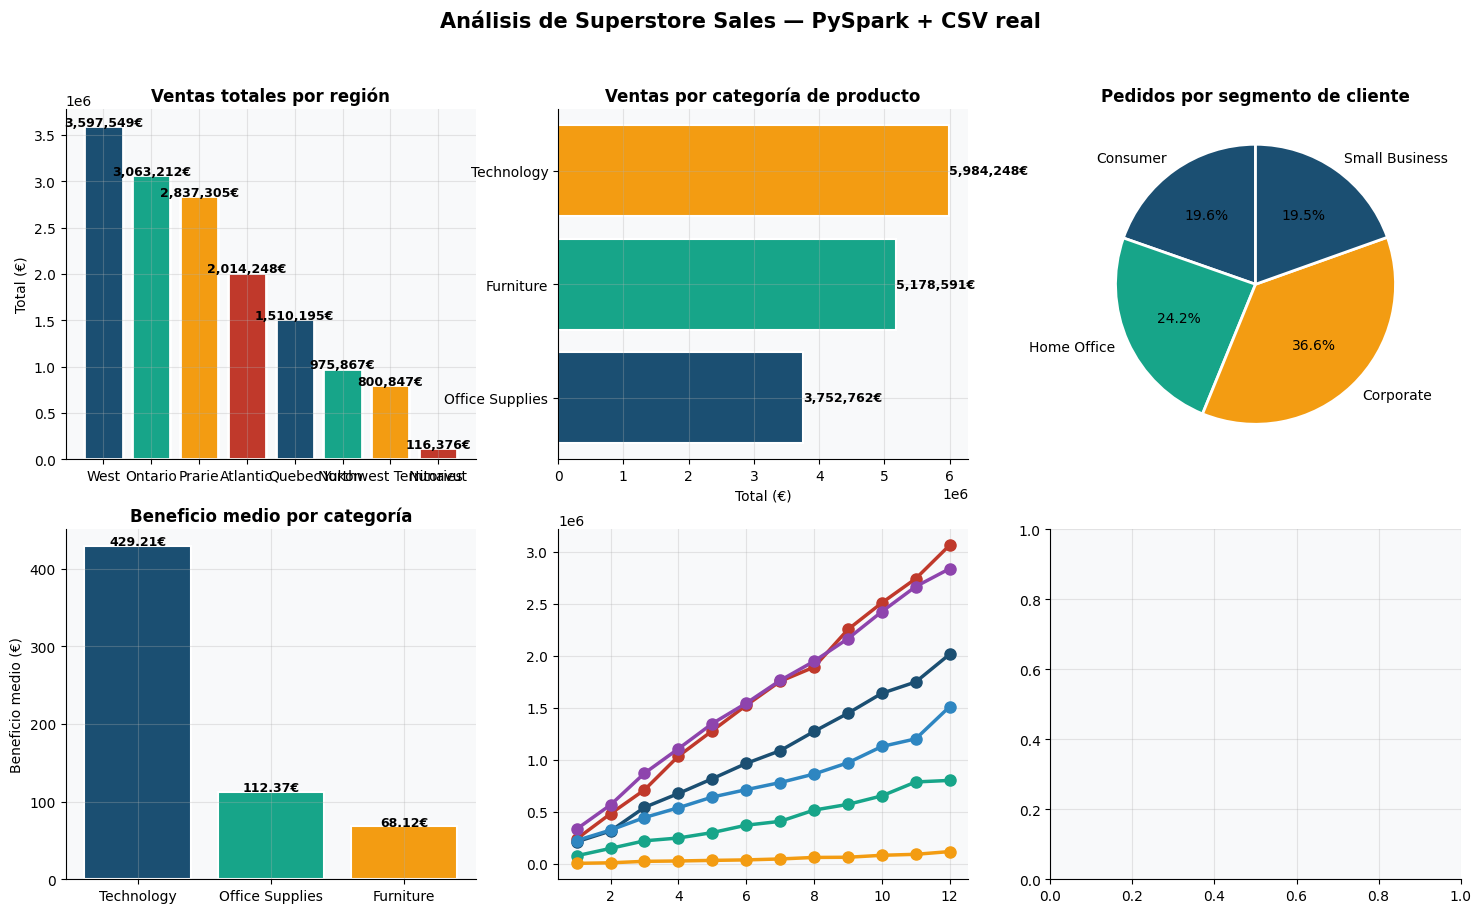

In [9]:
# ──────────────────────────────────────────────
# 5. DATAFRAMES — OPERACIONES Y AGRUPACIONES
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("5. DATAFRAMES — OPERACIONES Y AGRUPACIONES")
print("="*55)

# GROUP BY + agregaciones — igual que en SQL
print("Ventas por categoría de producto:")
df_ventas.groupBy("categoria") \
    .agg(
        F.sum("total").alias("ventas_totales"),
        F.avg("precio_unitario").alias("precio_medio"),
        F.sum("cantidad").alias("unidades_vendidas"),
        F.count("id_pedido").alias("num_pedidos")
    ) \
    .orderBy("ventas_totales", ascending=False) \
    .show()

# SQL directo sobre el DataFrame
# Spark permite usar SQL estándar registrando el DataFrame como tabla temporal
df_ventas.createOrReplaceTempView("ventas")

print("Top 5 provincias por beneficio (SQL directo):")
spark.sql("""
    SELECT provincia,
           ROUND(SUM(beneficio), 2)  AS beneficio_total,
           ROUND(AVG(descuento), 3)  AS descuento_medio,
           COUNT(id_pedido)          AS num_pedidos
    FROM ventas
    GROUP BY provincia
    ORDER BY beneficio_total DESC
    LIMIT 5
""").show()


# ──────────────────────────────────────────────
# 6. JOINs ENTRE DATAFRAMES
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("6. JOINs ENTRE DATAFRAMES")
print("="*55)

# Creamos un DataFrame auxiliar con info adicional de cada región
# Simula leer de una segunda fuente de datos
datos_regiones = [
    ("West",    "Oeste",   "USD", 15),
    ("East",    "Este",    "USD", 18),
    ("Central", "Centro",  "USD", 12),
    ("South",   "Sur",     "USD", 10),
]
df_regiones = spark.createDataFrame(
    datos_regiones,
    ["region", "region_es", "moneda", "num_almacenes"]
)
print("DataFrame auxiliar de regiones:")
df_regiones.show()

# INNER JOIN — solo registros que coinciden en ambos DataFrames
print("INNER JOIN — ventas enriquecidas con info de región:")
df_join = df_ventas.join(df_regiones, on="region", how="inner")
df_join.select("id_pedido","region","region_es","num_almacenes","total","categoria") \
       .show(5)

# LEFT JOIN — todos los de la izquierda aunque no tengan coincidencia
# Creamos descuentos solo para algunas categorías
datos_desc = [
    ("Technology",       0.05),
    ("Office Supplies",  0.10),
]
df_desc = spark.createDataFrame(datos_desc, ["categoria","descuento_extra"])

print("LEFT JOIN — categorías con y sin descuento extra:")
df_left = df_ventas.join(df_desc, on="categoria", how="left")
df_left = df_left.withColumn(
    "precio_final",
    F.when(F.col("descuento_extra").isNotNull(),
           F.col("total") * (1 - F.col("descuento_extra")))
     .otherwise(F.col("total"))
)
df_left.select("categoria","total","descuento_extra","precio_final") \
       .groupBy("categoria","descuento_extra") \
       .agg(F.round(F.sum("precio_final"),2).alias("total_final")) \
       .orderBy("categoria") \
       .show()


# ──────────────────────────────────────────────
# 7. WINDOW FUNCTIONS
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("7. WINDOW FUNCTIONS — Análisis avanzado")
print("="*55)

# Las Window Functions calculan estadísticas por grupos
# sin perder el detalle de cada fila individual
# Equivalen al OVER(PARTITION BY) de SQL

# Ranking de ventas dentro de cada región
ventana_region = Window.partitionBy("region").orderBy(F.col("total").desc())

df_rank = df_ventas.withColumn("ranking_en_region", F.rank().over(ventana_region))
print("Top 3 ventas por región:")
df_rank.filter(F.col("ranking_en_region") <= 3) \
       .select("region","id_pedido","categoria","total","ranking_en_region") \
       .orderBy("region","ranking_en_region") \
       .show(12)

# Ventas acumuladas por mes dentro de cada región
ventana_acum = Window.partitionBy("region").orderBy("mes") \
                     .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_acum = df_ventas.groupBy("region","mes") \
    .agg(F.round(F.sum("total"),2).alias("ventas_mes")) \
    .withColumn("ventas_acumuladas", F.round(F.sum("ventas_mes").over(ventana_acum),2))

print("Ventas acumuladas por región y mes:")
df_acum.orderBy("region","mes").show()


# ──────────────────────────────────────────────
# 8. ESTADÍSTICAS
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("8. ESTADÍSTICAS DESCRIPTIVAS")
print("="*55)

# describe() calcula automáticamente count, mean, stddev, min, max
print("Estadísticas de las columnas numéricas clave:")
df_ventas.select("total","precio_unitario","cantidad","beneficio","descuento") \
         .describe() \
         .show()

# Estadísticas específicas
stats = df_ventas.agg(
    F.mean("total").alias("media_ventas"),
    F.stddev("total").alias("desv_tipica"),
    F.percentile_approx("total", 0.5).alias("mediana"),
    F.corr("total","beneficio").alias("correlacion_venta_beneficio")
).collect()[0]

print(f"Media de ventas:              {stats['media_ventas']:,.2f}€")
print(f"Desviación típica:            {stats['desv_tipica']:,.2f}€")
print(f"Mediana:                      {stats['mediana']:,.2f}€")
print(f"Correlación venta-beneficio:  {stats['correlacion_venta_beneficio']:.3f}")


# ──────────────────────────────────────────────
# 9. VISUALIZACIONES
# ──────────────────────────────────────────────
print("\n" + "="*55)
print("9. VISUALIZACIONES CON DATOS REALES")
print("="*55)

# Para visualizar convertimos los datos ya agregados a pandas
# Primero agregamos en Spark (distribuido), luego pasamos a pandas (local)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
COLORS = ['#1B4F72','#17A589','#F39C12','#C0392B','#8E44AD','#2E86C1']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis de Superstore Sales — PySpark + CSV real',
             fontsize=15, fontweight='bold')

# ── Gráfico 1: Ventas por región
df_r = df_ventas.groupBy("region") \
                .agg(F.round(F.sum("total"),2).alias("total_ventas")) \
                .orderBy("total_ventas", ascending=False) \
                .toPandas()
bars = axes[0,0].bar(df_r['region'], df_r['total_ventas'],
                      color=COLORS[:4], edgecolor='white', linewidth=2)
axes[0,0].set_title('Ventas totales por región', fontweight='bold')
axes[0,0].set_ylabel('Total (€)')
for bar, val in zip(bars, df_r['total_ventas']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f'{val:,.0f}€', ha='center', fontweight='bold', fontsize=9)

# ── Gráfico 2: Ventas por categoría
df_cat = df_ventas.groupBy("categoria") \
                  .agg(F.round(F.sum("total"),2).alias("total")) \
                  .orderBy("total", ascending=True) \
                  .toPandas()
bars2 = axes[0,1].barh(df_cat['categoria'], df_cat['total'],
                        color=COLORS[:3], edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Ventas por categoría de producto', fontweight='bold')
axes[0,1].set_xlabel('Total (€)')
for bar, val in zip(bars2, df_cat['total']):
    axes[0,1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                   f'{val:,.0f}€', va='center', fontsize=9, fontweight='bold')

# ── Gráfico 3: Distribución por segmento de cliente
df_seg = df_ventas.groupBy("segmento") \
                  .agg(F.count("id_pedido").alias("num_pedidos")) \
                  .toPandas()
axes[0,2].pie(df_seg['num_pedidos'], labels=df_seg['segmento'],
              colors=COLORS[:3], autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,2].set_title('Pedidos por segmento de cliente', fontweight='bold')

# ── Gráfico 4: Beneficio medio por categoría
df_ben = df_ventas.groupBy("categoria") \
                  .agg(F.round(F.avg("beneficio"),2).alias("beneficio_medio")) \
                  .orderBy("beneficio_medio", ascending=False) \
                  .toPandas()
bars3 = axes[1,0].bar(df_ben['categoria'], df_ben['beneficio_medio'],
                       color=COLORS[:3], edgecolor='white', linewidth=1.5)
axes[1,0].set_title('Beneficio medio por categoría', fontweight='bold')
axes[1,0].set_ylabel('Beneficio medio (€)')
for bar, val in zip(bars3, df_ben['beneficio_medio']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:,.2f}€', ha='center', fontsize=9, fontweight='bold')

# ── Gráfico 5: Ventas acumuladas por mes y región
df_acum_pd = df_acum.orderBy("region","mes").toPandas()
for i, region in enumerate(df_acum_pd['region'].unique()):
    subset = df_acum_pd[df_acum_pd['region'] == region]
    axes[1,1].plot(subset['mes'], subset['ventas_acumuladas'],
                   marker='o', label=region, color=COLORS[i],
                   linewidth=2.5, markersize=8)
axes[1,1].set_title('Ventas acumuladas por mes y región\n(Window Function)',
                     fontweight='bold')
axes[1,1].set_xlabel('Mes')
axes[1,1].set_ylabel('Ventas acumuladas (€)')
axes[1,1].legend()

# ── Gráfico 6: Scatter precio vs beneficio
df_sc = df_ventas.select("precio_unitario","beneficio","categoria") \
                 .sample(fraction=0.3) \
                 .toPandas()
categorias = df_sc['categoria'].unique()
color_map = {cat: COLORS[i] for i, cat in enumerate(categorias)}
for cat in categorias:
    subset = df_sc[df_sc['categoria'] == cat]
    axes[1,2].scatter(subset['precio_unitario'], subset['beneficio'],
                      c=color_map[cat], alpha=0.4, s=30, label=cat)
axes[1,2].set_title('Precio unitario vs Beneficio', fontweight='bold')
axes[1,2].set_xlabel('Precio unitario (€)')
axes[1,2].set_ylabel('Beneficio (€)')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('pyspark_superstore.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Notebook completo")
print("\nResumen de conceptos vistos:")
print("  · requests + CSV      → descargar datos reales desde URL")
print("  · inferSchema         → Spark detecta tipos automáticamente")
print("  · withColumnRenamed   → renombrar columnas")
print("  · RDD                 → estructura distribuida fundamental")
print("  · map()               → transformar cada elemento en paralelo")
print("  · reduce()            → agregar todos los elementos")
print("  · reduceByKey()       → patrón MapReduce clásico")
print("  · groupBy/agg         → agrupaciones y estadísticas")
print("  · SQL directo         → consultas SQL sobre DataFrames")
print("  · INNER JOIN          → combinar DataFrames por columna común")
print("  · LEFT JOIN           → todos los de la izquierda + coincidencias")
print("  · Window Functions    → ranking y acumulados por grupos")
print("  · describe()          → estadísticas descriptivas automáticas")
print("  · toPandas()          → convertir a pandas para visualizar")

spark.stop()